## Illustration de la régression linéaire multiple

Jeu California Housing et scikit-learn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#### 1. Chargement du jeu de données



In [2]:
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = california.target  # Valeur médiane des maisons (en 100 000 $)

print("📦 Jeu de données chargé :", X.shape[0], "échantillons,", X.shape[1], "variables explicatives")


📦 Jeu de données chargé : 20640 échantillons, 8 variables explicatives


Input attributes information (variables $x^j$ of $x$):
- MedInc        median income in block group
- HouseAge      median house age in block group
- AveRooms      average number of rooms per household
- AveBedrms     average number of bedrooms per household
- Population    block group population
- AveOccup      average number of household members
- Latitude      block group latitude
- Longitude     block group longitude

The target variable $y$ is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

#### 2. Séparation entraînement / test


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### 3. Initialisation et entraînement du modèle


In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

#### 4. Prédictions sur le jeu de test


In [5]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self

#### 5. Évaluation du modèle


In [6]:
mse = mean_squared_error(y_train, y_train_pred)
r2 = r2_score(y_train, y_train_pred)

print("\n📊 Métriques d'évaluation (train) :")
print(f"   • Erreur quadratique moyenne (MSE) : {mse:.2f}")
print(f"   • Score R² : {r2:.2f} (proportion de variance expliquée)")


mse = mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("\n📊 Métriques d'évaluation (test) :")
print(f"   • Erreur quadratique moyenne (MSE) : {mse:.2f}")
print(f"   • Score R² : {r2:.2f} (proportion de variance expliquée)")


📊 Métriques d'évaluation (train) :
   • Erreur quadratique moyenne (MSE) : 0.52
   • Score R² : 0.61 (proportion de variance expliquée)

📊 Métriques d'évaluation (test) :
   • Erreur quadratique moyenne (MSE) : 0.56
   • Score R² : 0.58 (proportion de variance expliquée)


#### 6. Affichage des coefficients


In [7]:
print("\n🔍 Coefficients du modèle (y = β₀ + β₁x₁ + β₂x₂ + ...) :")
coef_df = pd.DataFrame({
    'Variable': ['Intercepte'] + california.feature_names,
    'Coefficient': [model.intercept_] + list(model.coef_)
})
print(coef_df.to_string(index=False))


🔍 Coefficients du modèle (y = β₀ + β₁x₁ + β₂x₂ + ...) :
  Variable  Coefficient
Intercepte   -37.023278
    MedInc     0.448675
  HouseAge     0.009724
  AveRooms    -0.123323
 AveBedrms     0.783145
Population    -0.000002
  AveOccup    -0.003526
  Latitude    -0.419792
 Longitude    -0.433708


#### 7. Visualisation : Réel vs Prédit


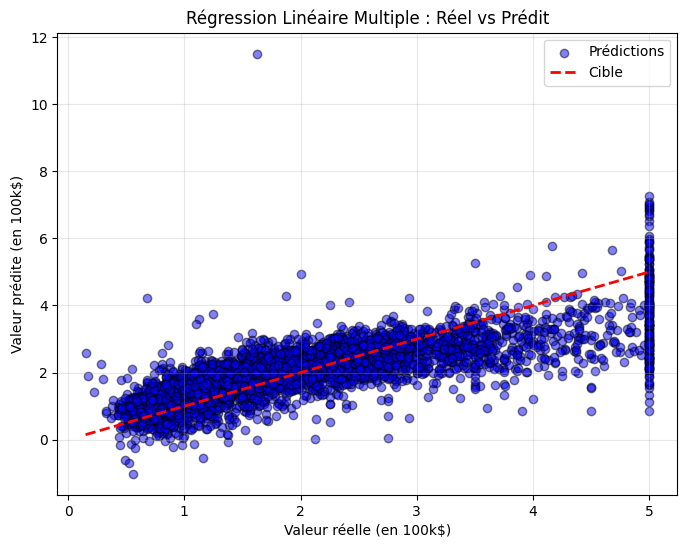

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5, color='blue', edgecolor='black', label='Prédictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Cible')
plt.xlabel('Valeur réelle (en 100k$)')
plt.ylabel('Valeur prédite (en 100k$)')
plt.title('Régression Linéaire Multiple : Réel vs Prédit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

On constate un seuil pour les logements de plus de $500k\$$. Il pourrait induire le décrochage de qualité de prédictions à partir de $300k\$$

#### 8. Visualisation : Impact des variables


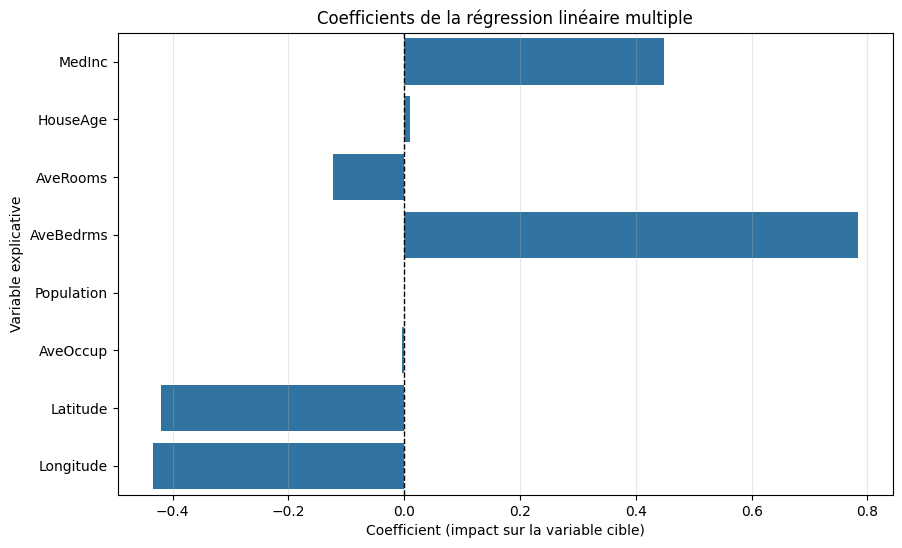

In [9]:
coef2drop = coef_df[((coef_df.Variable == 'Intercepte'))].index

plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.drop(coef2drop), x='Coefficient', y='Variable')
plt.title('Coefficients de la régression linéaire multiple')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Coefficient (impact sur la variable cible)')
plt.ylabel('Variable explicative')
plt.grid(axis='x', alpha=0.3)
plt.show()